# Exploration approfondie de la base d'apprentissage

L'objectif de cette étape est de réaliser une **analyse exploratoire des données** afin d'extraire les premières tendances et de comprendre la structure de nos données.

> L'ensemble de l'EDA est mené **exclusivement sur le jeu d'entraînement (`train`)**. 
> Ce choix garantit l'absence totale de fuite d'information (*data leakage*) vis-à-vis des ensembles de validation et de test. Toutes les décisions de prétraitement (imputation des valeurs manquantes, encodage, normalisation) et de *feature engineering* découleront uniquement des statistiques observées sur ce jeu de données.

Nous allons analyser la distribution des variables, identifier d'éventuelles anomalies ou valeurs manquantes, et étudier les relations entre les variables explicatives et la cible.

## Partie A : Import de fonctions utiles à l'exploration de la base d'apprentissage

In [ ]:
# Importation des packages nécessaires

import pandas as pd
import sys
import os
import warnings

warnings.filterwarnings("ignore")

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 2

from eda import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Partie B : Le traitement et l'analyse du jeu d'entraînement

### B1 : Configuration initiale

In [58]:
# Paramètres fixes

FILE_PATH = "../data_finale/train.csv"
TARGET    = "market_value_in_eur"
dossier_sauvegarde = "../outputs/eda"

In [59]:
# Chargement de la base de données

df_base = pd.read_csv(FILE_PATH)

### B2 : Vérification de la qualité des données

Suite au nettoyage précédent, nous vérifions que nous pouvons bien analyser une base d'apprentissage propre, en vérifiant son état en ce qui concerne les valeurs manquantes ou encore si les variables suivent des distributions logiques.

Analyse des valeurs manquantes
                     nb_missing    pct
xg_buildup                 4255  57.47
xa                         4255  57.47
Subs_Mn/Sub                1092  14.75
Team Success_On-Off          57   0.77
Team Success_PPM              5   0.07
height_in_cm                  2   0.03
nation                        1   0.01
xg                            1   0.01

Graphique sauvegardé sous : ..\outputs\eda\valeurs_manquantes.png


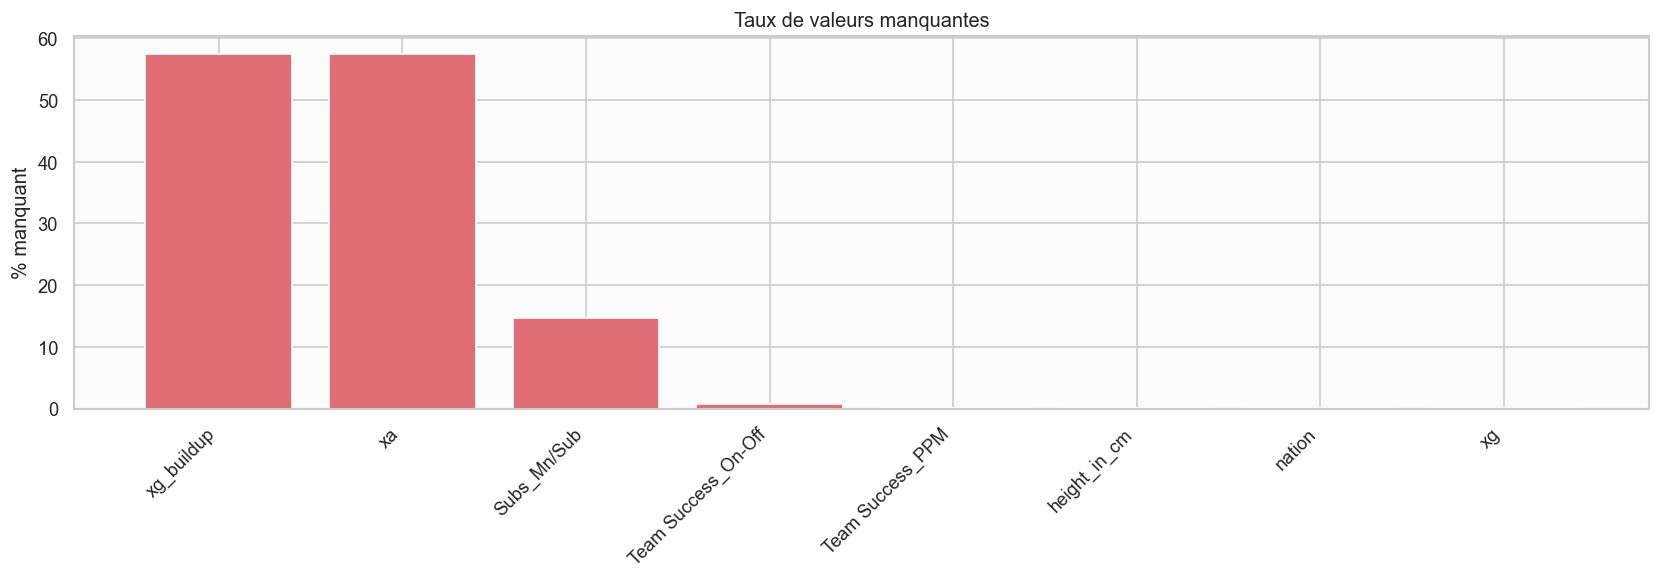

In [60]:
# On vérifie qu'il y a peu de valeurs manquantes dans la base de données

analyser_valeurs_manquantes(df_base, dossier_sauvegarde=dossier_sauvegarde)

Analyse de la variable cible : market_value_in_eur
count          7,404
mean      10,844,760
std       15,537,143
min           50,000
25%        2,000,000
50%        5,000,000
75%       14,000,000
max      180,000,000
Name: market_value_in_eur, dtype: str

Graphique sauvegardé sous : ..\outputs\eda\distribution_market_value_in_eur.png


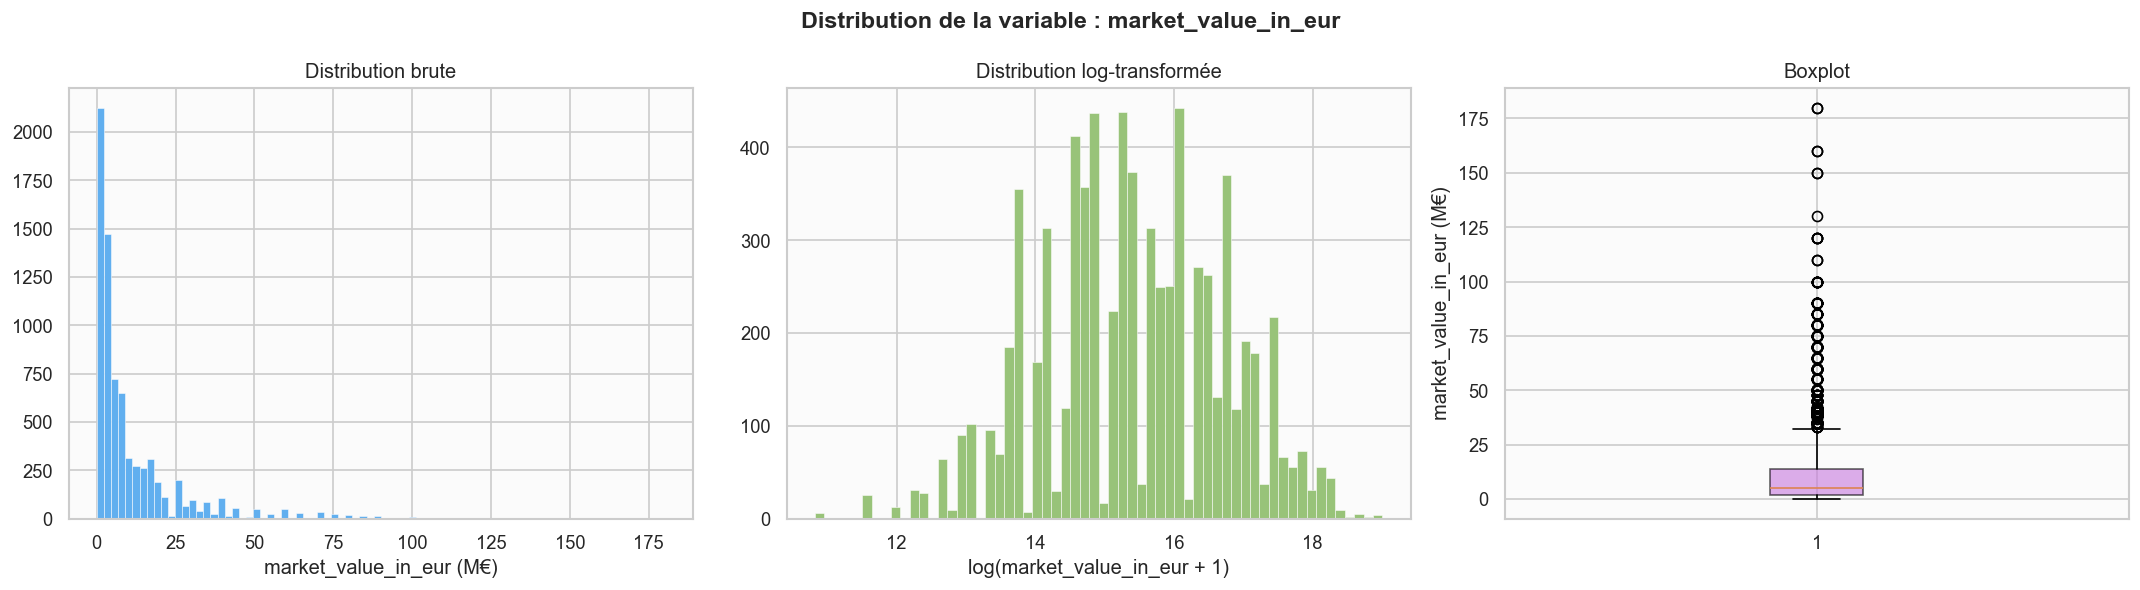

In [61]:
# On analyse la variable cible

analyser_variable_cible(df_base, target_col=TARGET, dossier_sauvegarde=dossier_sauvegarde)

Distributions des variables numériques clés

Graphique sauvegardé sous : ..\outputs\eda\distributions_variables_numeriques_cles.png


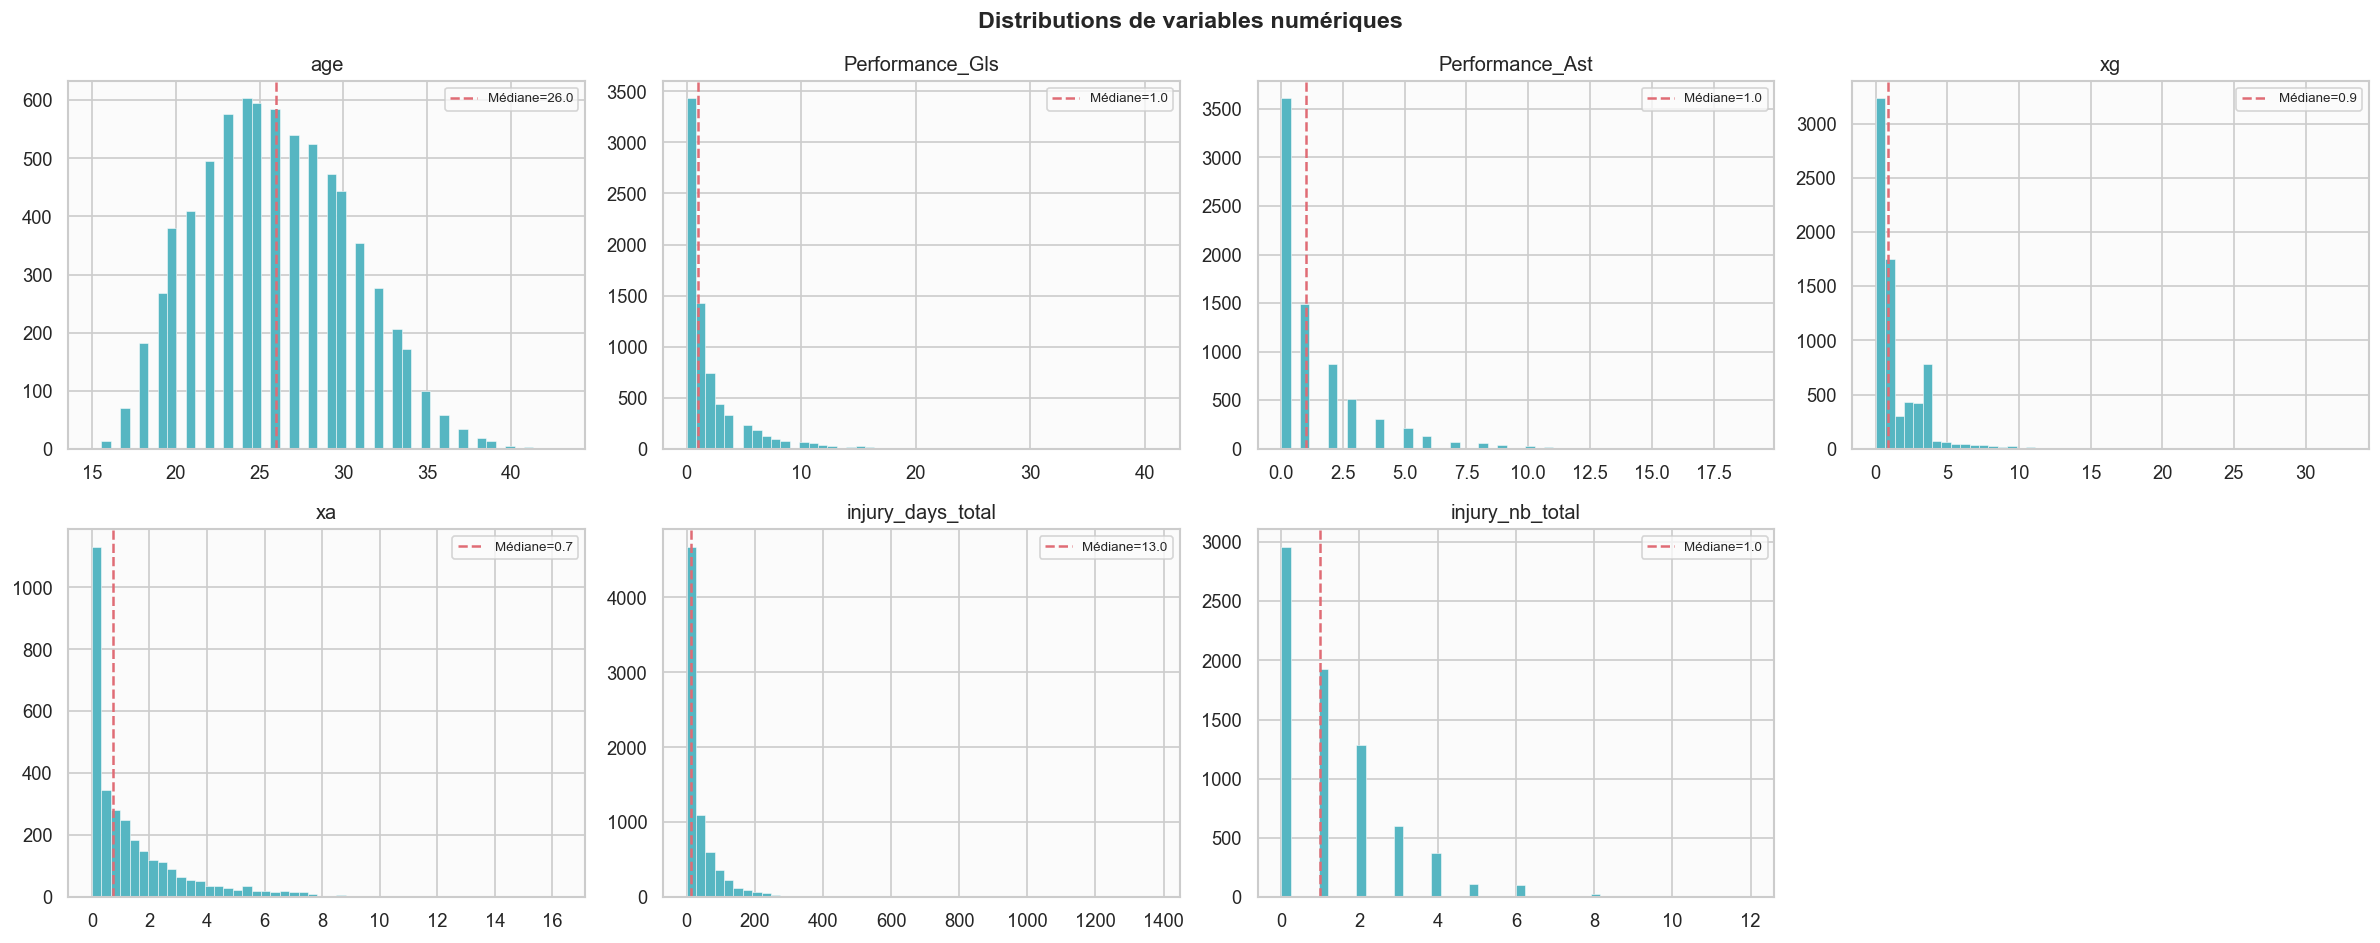

In [62]:
# On analyse les variables numériques

analyser_distributions_numeriques(df_base, cols_a_analyser=None, dossier_sauvegarde=dossier_sauvegarde)

### B3 : L'analyse des répartitions

On vérifie s'il y a une proportion logique de joueurs par ligue, par poste ou encore par nationalité.

Analyse des variables catégorielles

ligue (5 modalités encodées) :
ITA-Serie A           1563
FRA-Ligue 1           1534
ESP-La Liga           1518
ENG-Premier League    1448
GER-Bundesliga        1341

players_top_nations.png sauvegardé


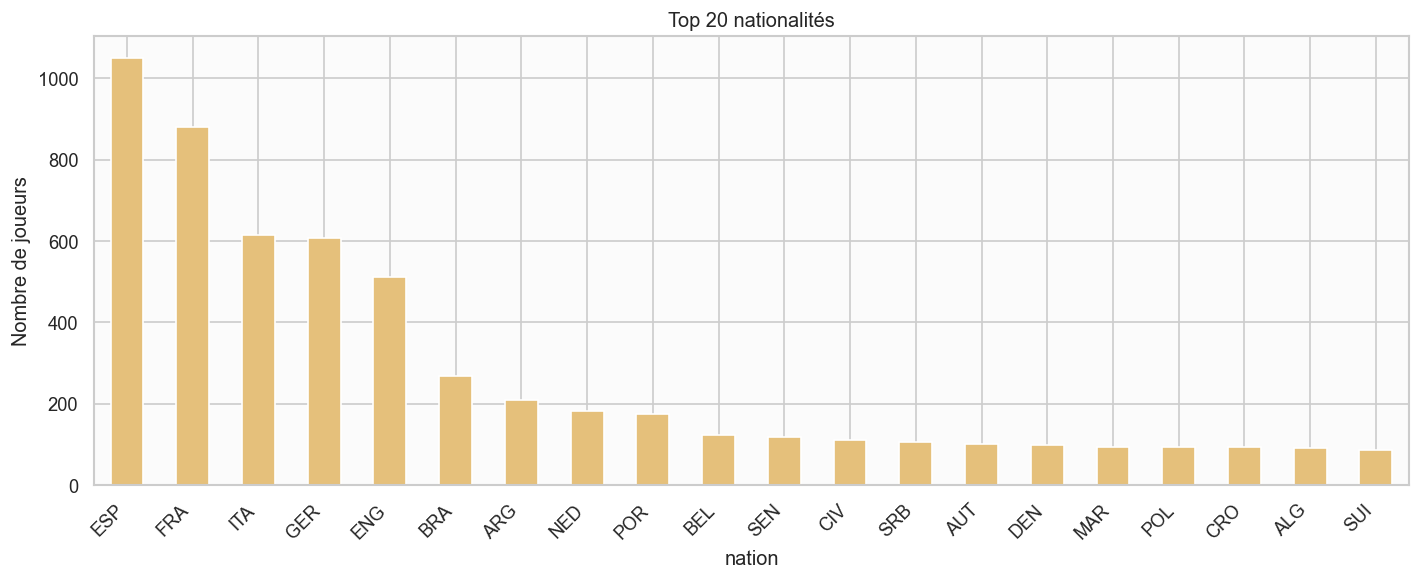

position.png sauvegardé


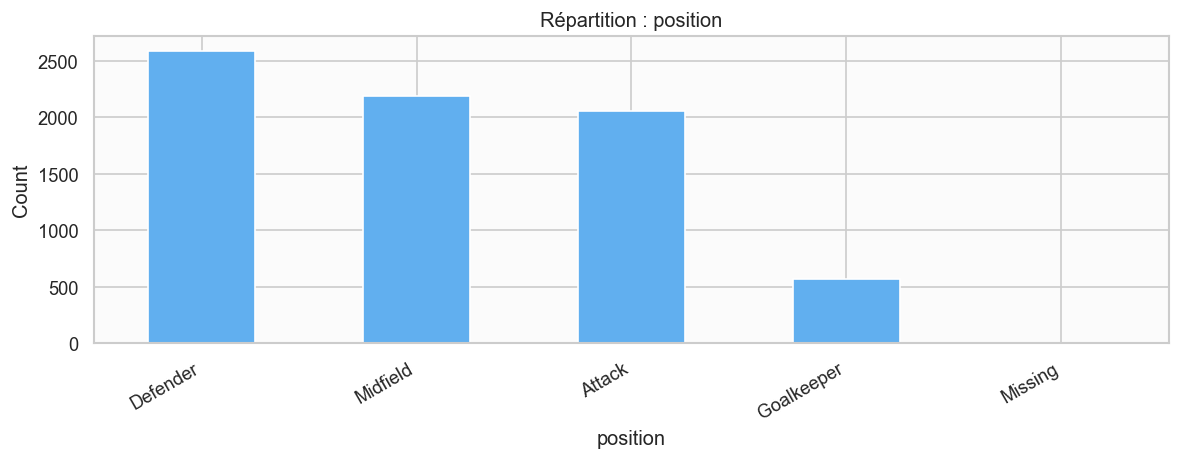

league.png sauvegardé


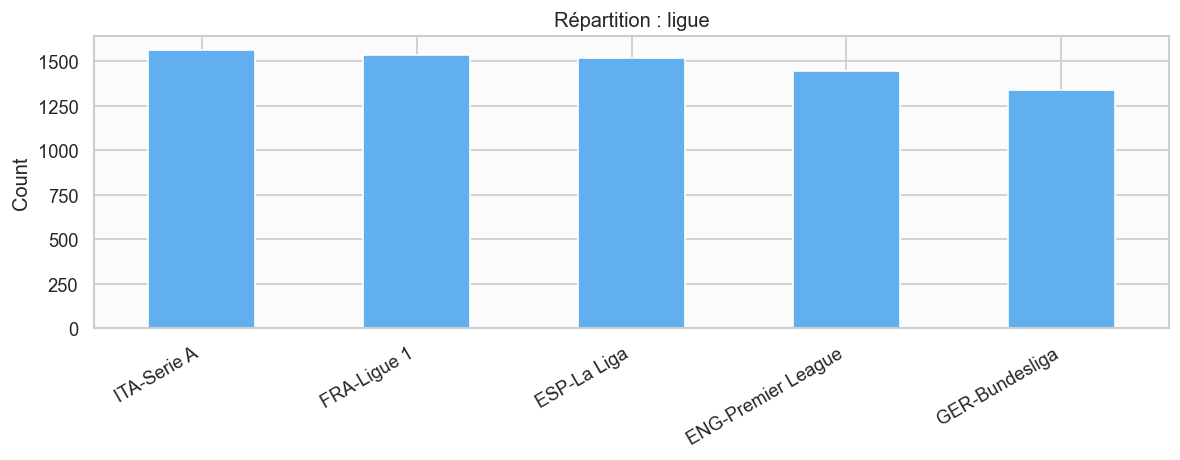

In [63]:
# On analyse ceryaines variables catégorielles

analyser_repartitions(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

### B4 : Des premières analyses de corrélation

Nous réalisons au préalable une sélection de variables que nous pensons corrélées à la valeur marchande pour le vérifier.

Analyse des corrélations (cible : market_value_in_eur)

Corrélation linéaire avec la cible (variables clés)
                     market_value_in_eur
market_value_in_eur             1.000000
xa                              0.482819
Performance_Gls                 0.478500
Performance_Ast                 0.459568
xg                              0.294481
injury_nb_total                 0.111816
injury_days_total               0.026712
age                            -0.156288

matrice_correlation.png sauvegardé sous : ..\outputs\eda\matrice_correlation.png


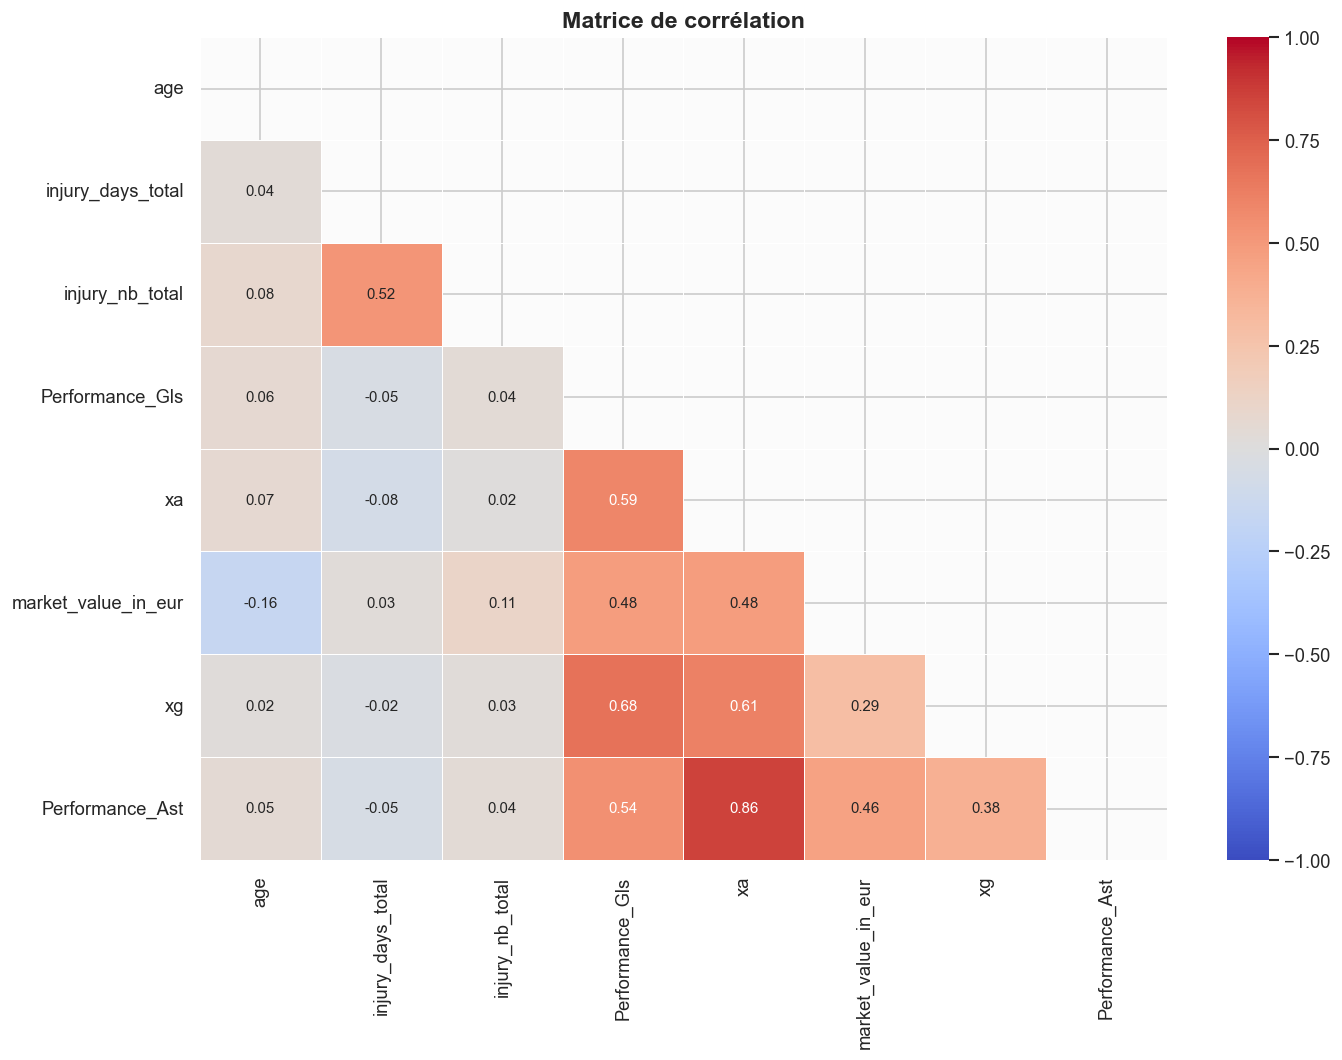


Top 20 des corrélations absolues avec market_value_in_eur (Toutes variables numériques)
Team Success_onG       0.576348
log_prev_value         0.562810
xg_buildup             0.557678
Standard_Sh            0.492466
Standard_SoT           0.485281
Performance_G-PK       0.483923
xa                     0.482819
Performance_Gls        0.478500
Performance_Ast        0.459568
Playing Time_90s       0.385506
classement             0.385185
Playing Time_Starts    0.383666
Performance_Fld        0.355313
Playing Time_MP        0.354287
Team Success_PPM       0.335356
Starts_Compl           0.306113
xg                     0.294481
Subs_unSub             0.290985
Playing Time_Mn/MP     0.277455
Performance_Off        0.272054


In [64]:
# On analyse les corrélations entre certaines variables numériques et la variable cible

analyser_correlations(df_base, TARGET, cols_cles=None, dossier_sauvegarde=dossier_sauvegarde)

### B5 : Segmentation par poste

Nous essayons de déterminer si les postes ont une influence forte sur la valeur marchande ou non.

Analyse du profil médian par poste

Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_profil_poste.png


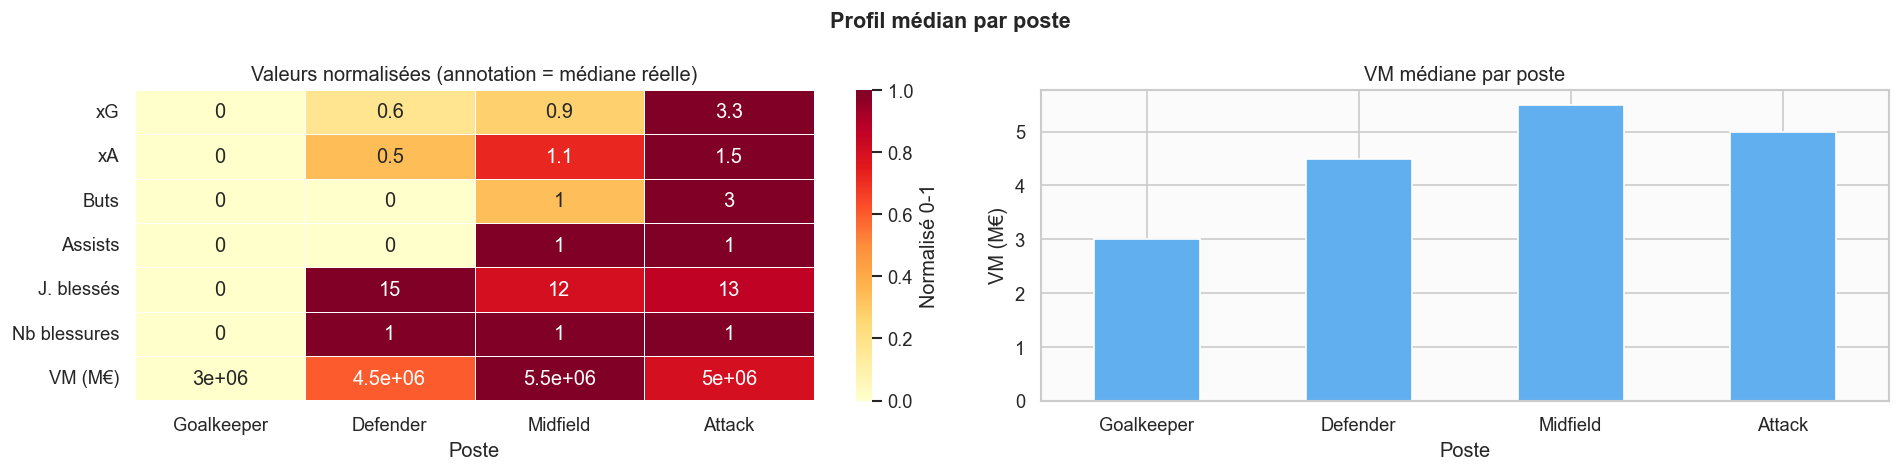

In [65]:
# Nous calculons les valeurs normalisées de certaines variables numériques pour les analyser par poste

analyser_profil_par_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

Analyse de la distribution des âges par poste
Graphique sauvegardé sous : ..\outputs\eda\segmentation_par_poste_age_par_poste.png


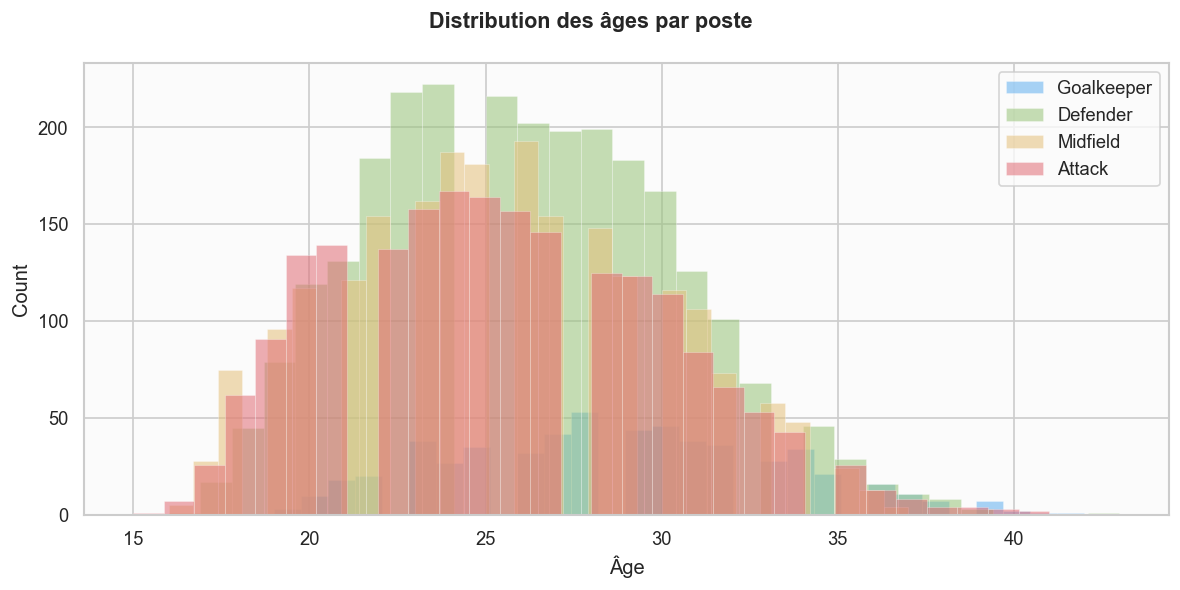


Âge médian par poste
position
Goalkeeper    29.0
Defender      26.0
Midfield      25.0
Attack        25.0


In [66]:
# On analyse les âges des joueurs par poste

analyser_ages_par_poste(df_base, dossier_sauvegarde=dossier_sauvegarde, liste_couleurs=None)

Analyse croisée : valeur marchande médiane par championnat et par poste

Heatmap sauvegardée sous : ..\outputs\eda\feature_engineered_heatmap_league_pos.png


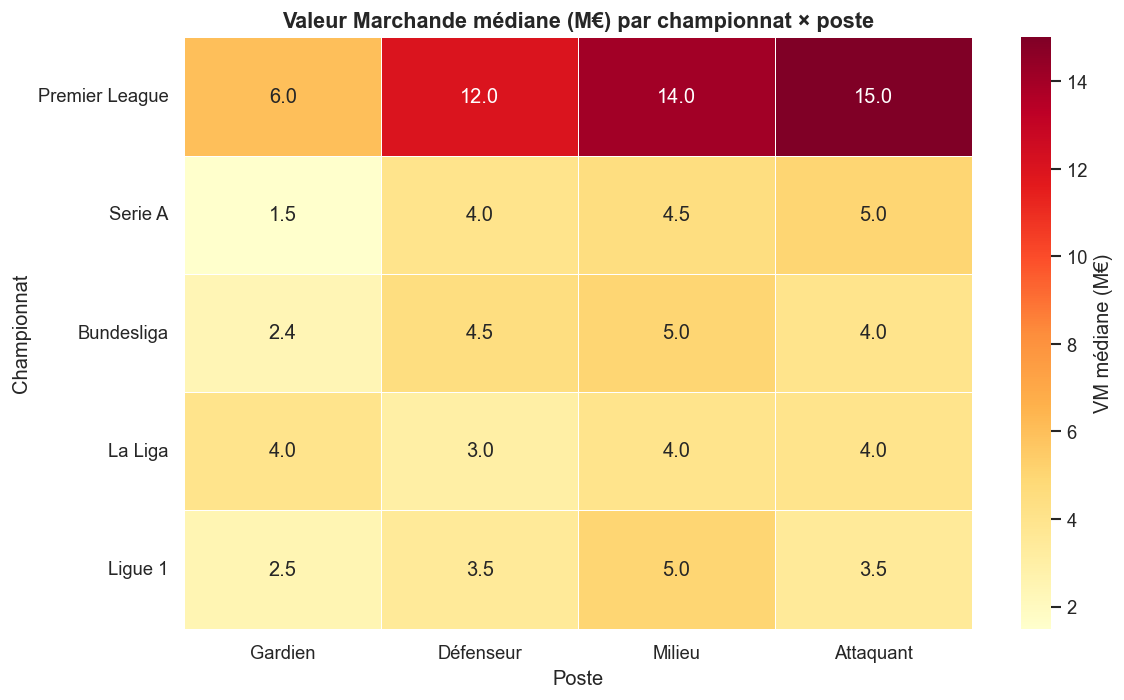

In [67]:
# On analyse les corrélations entre le poste et le championnat avec la variable cible

analyser_heatmap_league_poste(df_base, TARGET, dossier_sauvegarde=dossier_sauvegarde)

Démarrage de l'analyse de distribution des prix...
5 championnats détectés et ordonnés pour l'affichage.


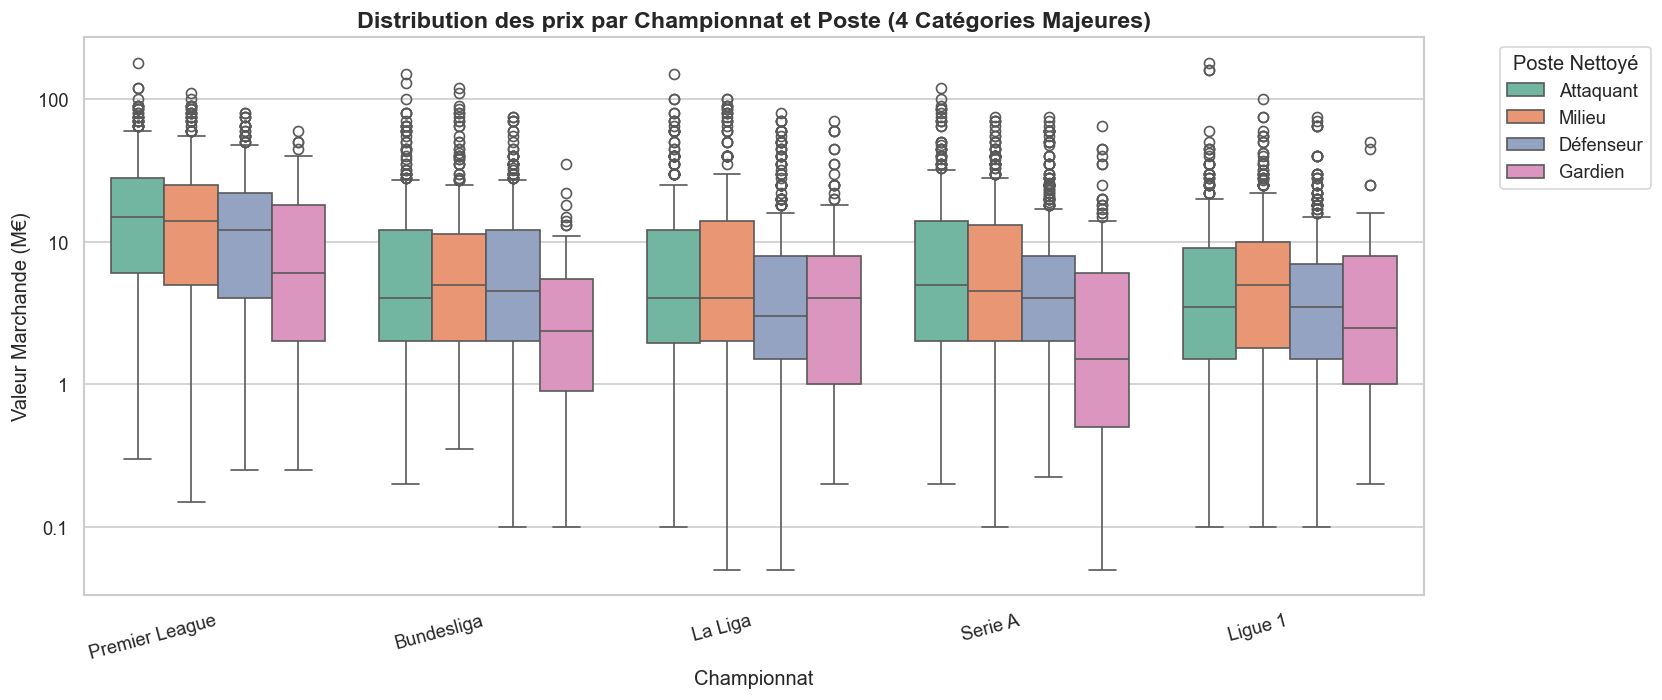


Boxplot généré avec succès.


In [68]:
analyser_distribution_prix_ligue_poste(df_base)

On perçoit ici que les joueurs les plus chers sont les plus offensifs.

Analyse des outliers et profils Spécifiques (cible : market_value_in_eur)

Joueurs avec market_value_in_eur ≥ 100M€ : 22 observations

Top 20 des joueurs les plus chers
           player position  market_value_in_eur  Performance_Gls        xg  Per 90 Minutes_G+A
   Erling Haaland   Attack                180.0               36 32.761400                1.43
    Kylian Mbappé   Attack                180.0               29  2.055070                1.09
    Kylian Mbappé   Attack                160.0               27  2.055070                1.29
    Kylian Mbappé   Attack                160.0               28  2.055070                1.34
  Vinicius Júnior   Attack                150.0               10  3.188221                0.61
   Erling Haaland   Attack                150.0               22  3.452661                1.42
   Erling Haaland   Attack                130.0               27  3.452661                1.24
   Victor Osimhen   Attack                120.0               26 26.626

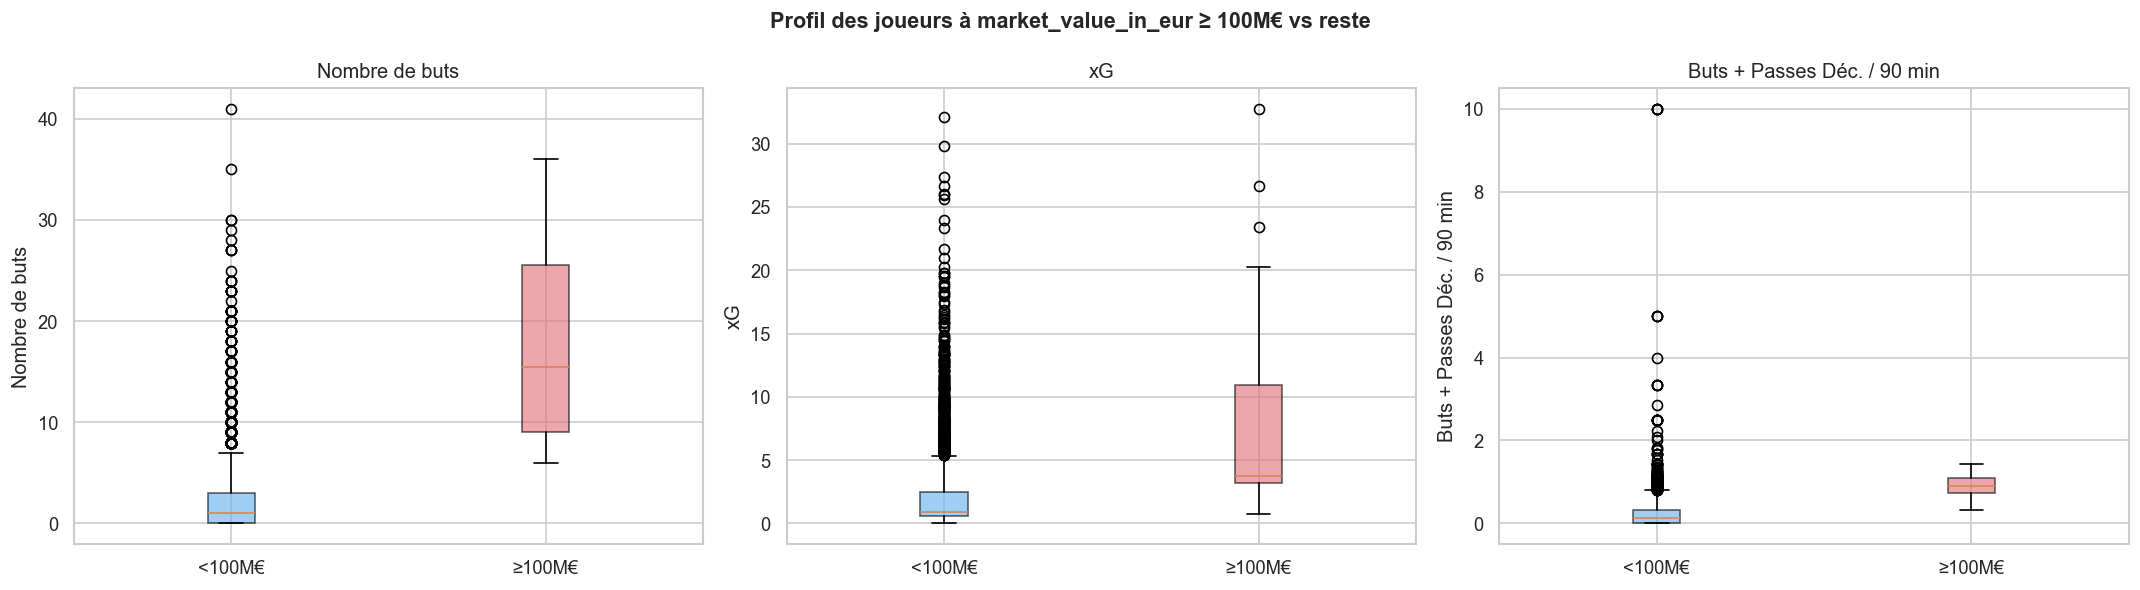

In [69]:
df_base_sans_gardiens = df_base[df_base['position'] != 'Goalkeeper']

analyser_profil_outliers(df_base_sans_gardiens, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

### B6 : Cohérence des données

On vérifie si le nombre de jours de blessures calculé est cohérent , et si les valeurs marchandes suivent une inflation comme vu dans la littérature scientifique.

In [70]:
verifier_coherence_jours_blessures(df_base)

Contrôle de cohérence : jours de blessures

Cohérence injury_days_total vs somme des composantes (7404/7404 lignes analysées) :
  Cohérents (diff = 0)           : 7,084
  Diff ≤ 1 jour                  : 7,084
  Diff > 1 jour (anomalie)       : 320
  Diff max                       : 1312 jours

Des incohérences ont été détectées. Cela peut provenir de blessures
 qui se chevauchent dans le temps ou de catégories non répertoriées ici.


Analyse de l'évolution temporelle par Saison (cible : market_value_in_eur)

Évolution VM par saison :
             Médiane (M€)  Moyenne (M€)  Nb joueurs
season_year                                        
2020                  5.0     10.579836        2502
2021                  5.0     10.694078        2423
2022                  5.0     11.259419        2479
2023                  5.0     12.006643        2431
2024                  6.0     13.005044        2295

Graphique sauvegardé sous : ..\outputs\eda\evolution_temporelle.png


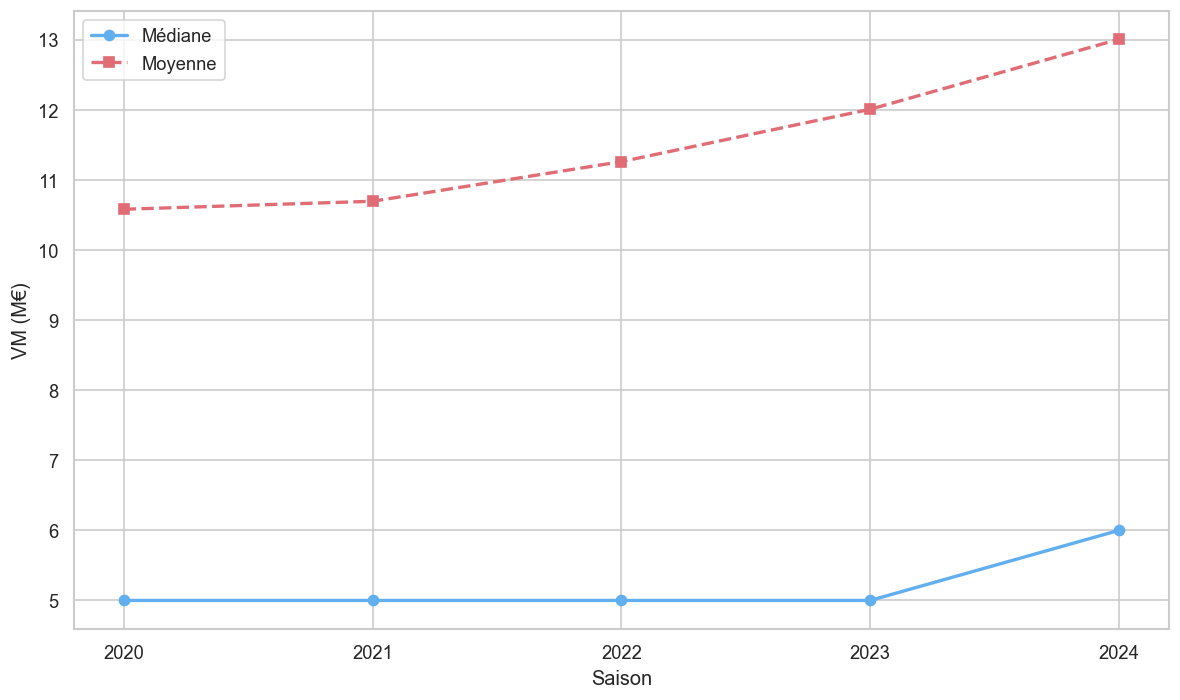

,Médiane (M€),Moyenne (M€),Nb joueurs
season_year,,,
2020,5.0,10.579836,2502
2021,5.0,10.694078,2423
2022,5.0,11.259419,2479
2023,5.0,12.006643,2431
2024,6.0,13.005044,2295


In [71]:
# On concatène les bases train, val et test pour analyser l'évolution temporelle de la variable cible

train = pd.read_csv("../data_finale/train.csv")
val = pd.read_csv("../data_finale/val.csv")
test = pd.read_csv("../data_finale/test.csv")

df = pd.concat([train, val, test], axis=0)

analyser_evolution_temporelle_saison(df, TARGET, dossier_sauvegarde=dossier_sauvegarde, couleurs_dict=None)

### B7 : L'effet de l'âge sur la valeur marchande

On vérifie si l'âge a une inflnce sur la valeur marchande.

Démarrage de l'analyse du cycle de vie financier...
7403 observations valides trouvées pour l'analyse graphique.


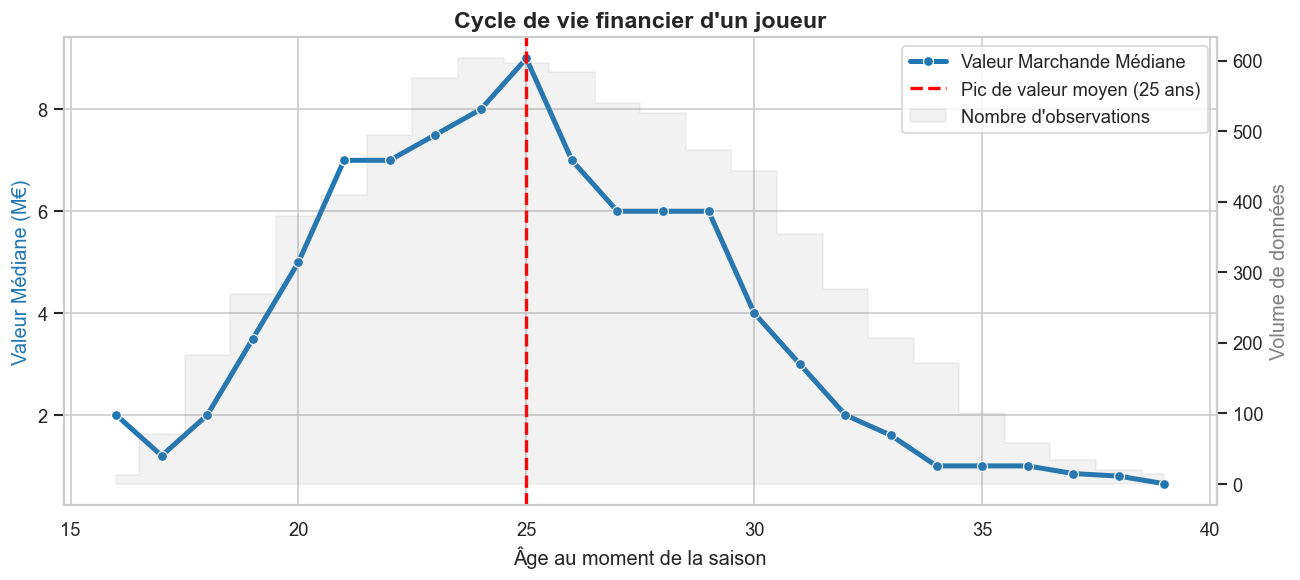


Graphique généré avec succès.


In [72]:
# Application de la fonction
df_base = analyser_cycle_vie_financier(df_base)

### B8 : Détection des variables les plus corrélées avec la valeur marchande

Nous regardons ici les variables les plus corrélées avec la valeur marchande. Nous pouvons choisir de ne sélectionner que les gardiens, qui ont un profil atypique, ou alors l'ensemble des joueurs.

Analyse des variables les plus explicatives pour : market_value_in_eur
Filtrage appliqué : Analyse exclusive des Gardiens de but.


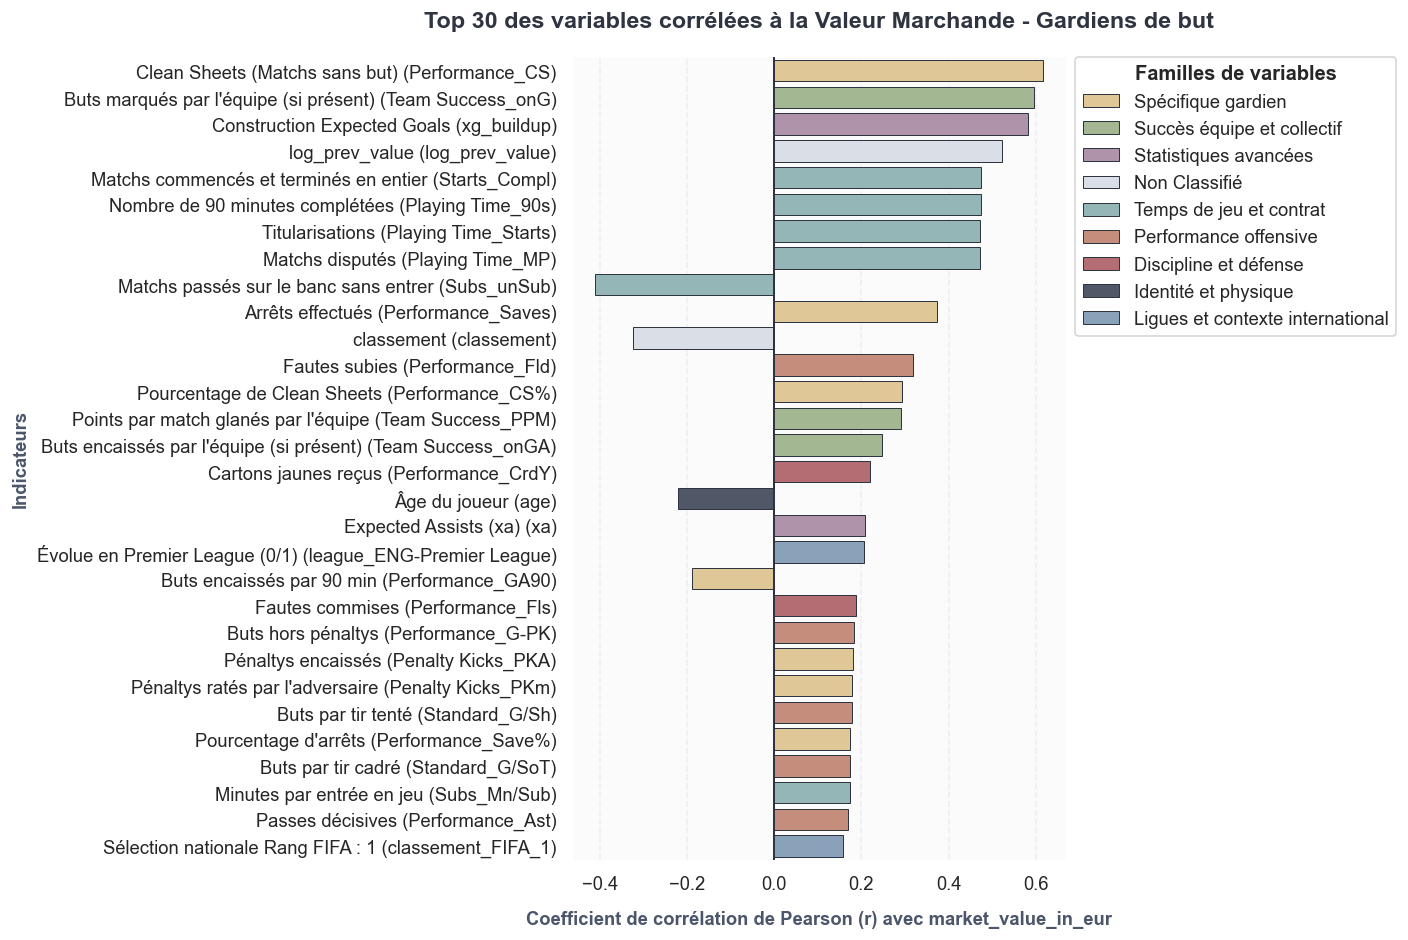

,Variable,Description,Famille,Corr_Cible_Brute
0,Performance_CS,Clean Sheets (Matchs sans but) (Performance_CS),Spécifique gardien,0.617
1,Team Success_onG,Buts marqués par l'équipe (si présent) (Team S...,Succès équipe et collectif,0.596
2,xg_buildup,Construction Expected Goals (xg_buildup),Statistiques avancées,0.582
3,log_prev_value,log_prev_value (log_prev_value),Non Classifié,0.522
4,Starts_Compl,Matchs commencés et terminés en entier (Starts...,Temps de jeu et contrat,0.474
5,Playing Time_90s,Nombre de 90 minutes complétées (Playing Time_...,Temps de jeu et contrat,0.474
6,Playing Time_Starts,Titularisations (Playing Time_Starts),Temps de jeu et contrat,0.473
7,Playing Time_MP,Matchs disputés (Playing Time_MP),Temps de jeu et contrat,0.473
8,Subs_unSub,Matchs passés sur le banc sans entrer (Subs_un...,Temps de jeu et contrat,-0.411
9,Performance_Saves,Arrêts effectués (Performance_Saves),Spécifique gardien,0.374


In [73]:
# On applique la fonction
tableau_importance = analyser_variables_les_plus_explicatives(df_base,
                                                              target_col=TARGET,
                                                              top_n=30,
                                                              afficher_nom_technique=True,
                                                              uniquement_gardiens=True)

# On affiche le tableau propre sous le graphique
display(tableau_importance)